In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data/neurosense_cleaned.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (37575, 361)
   eeg_feature_1  eeg_feature_2  eeg_feature_3  eeg_feature_4  eeg_feature_5  \
0      26.791522      24.062115      21.927618      19.697461      18.626858   
1      26.791101      24.061706      21.928215      19.697127      18.626882   
2      26.791650      24.062570      21.929218      19.696753      18.626936   
3      26.793695      24.063827      21.931248      19.696395      18.626931   
4      26.794138      24.064473      21.933663      19.696645      18.627109   

   eeg_feature_6  eeg_feature_7  eeg_feature_8  eeg_feature_9  eeg_feature_10  \
0      26.781416      24.090212      21.992052      19.634864       18.446852   
1      26.780972      24.089481      21.992834      19.634719       18.447054   
2      26.783116      24.090431      21.994368      19.634771       18.447366   
3      26.787306      24.092226      21.997363      19.634678       18.447735   
4      26.790289      24.093457      22.000899      19.635314       18.448518   

   .

In [2]:
X = df.drop(columns=["label", "subject", "session", "trial", "sample"])
X = X.select_dtypes(include=["number"])

y = df["label"]
groups = df["subject"]

print("Features:", X.shape)
print("Classes:", sorted(y.unique()))
print("Label distribution:")
print(y.value_counts())

Features: (37575, 355)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Label distribution:
label
0    9750
2    9735
1    9525
3    8565
Name: count, dtype: int64


In [3]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train subjects:", df.iloc[train_idx]["subject"].nunique())
print("Test subjects:", df.iloc[test_idx]["subject"].nunique())

Train shape: (30060, 355)
Test shape: (7515, 355)
Train subjects: 12
Test subjects: 3


In [4]:
#Linear SVM Basic
svm_basic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=10000
    ))
])

svm_basic_pipeline.fit(X_train, y_train)

y_pred_basic = svm_basic_pipeline.predict(X_test)

basic_results = {
    "Model": "Linear SVM Basic GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_basic),
    "Precision": precision_score(y_test, y_pred_basic, average="weighted"),
    "Recall": recall_score(y_test, y_pred_basic, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_basic, average="weighted"),
    "Best Parameters": "LinearSVC default, class_weight=balanced"
}

basic_results

{'Model': 'Linear SVM Basic GroupSplit 4-Class',
 'Accuracy': 0.3087159015302728,
 'Precision': 0.3189388459291071,
 'Recall': 0.3087159015302728,
 'F1-score': 0.29204048031738805,
 'Best Parameters': 'LinearSVC default, class_weight=balanced'}

              precision    recall  f1-score   support

           0       0.29      0.56      0.38      1950
           1       0.27      0.13      0.18      1905
           2       0.42      0.26      0.32      1947
           3       0.29      0.27      0.28      1713

    accuracy                           0.31      7515
   macro avg       0.32      0.31      0.29      7515
weighted avg       0.32      0.31      0.29      7515



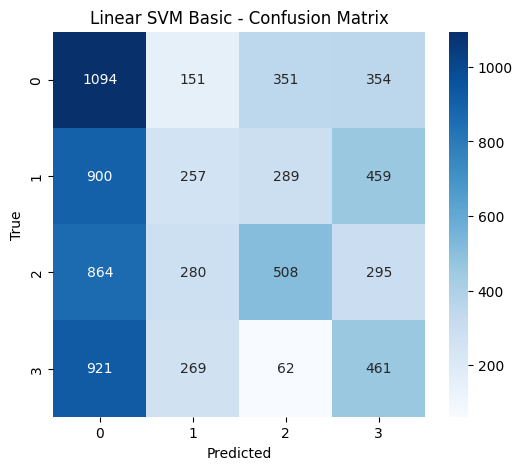

In [5]:
print(classification_report(y_test, y_pred_basic))
cm_basic = confusion_matrix(y_test, y_pred_basic)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_basic, annot=True, fmt="d", cmap="Blues")
plt.title("Linear SVM Basic - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [6]:
#SVM + PCA
pca_components = [20, 50, 100, 150]

pca_results = []

for n in pca_components:
    svm_pca_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n, random_state=42)),
        ("svm", LinearSVC(
            class_weight="balanced",
            random_state=42,
            max_iter=10000
        ))
    ])

    svm_pca_pipeline.fit(X_train, y_train)

    y_pred_pca = svm_pca_pipeline.predict(X_test)

    result = {
        "Model": f"Linear SVM + PCA {n} GroupSplit 4-Class",
        "Accuracy": accuracy_score(y_test, y_pred_pca),
        "Precision": precision_score(y_test, y_pred_pca, average="weighted"),
        "Recall": recall_score(y_test, y_pred_pca, average="weighted"),
        "F1-score": f1_score(y_test, y_pred_pca, average="weighted"),
        "Best Parameters": f"PCA n_components={n}, LinearSVC default"
    }

    pca_results.append(result)

pd.DataFrame(pca_results)

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Linear SVM + PCA 20 GroupSplit 4-Class,0.316966,0.303445,0.316966,0.298994,"PCA n_components=20, LinearSVC default"
1,Linear SVM + PCA 50 GroupSplit 4-Class,0.379375,0.403576,0.379375,0.342244,"PCA n_components=50, LinearSVC default"
2,Linear SVM + PCA 100 GroupSplit 4-Class,0.345842,0.388720,0.345842,0.327787,"PCA n_components=100, LinearSVC default"
3,Linear SVM + PCA 150 GroupSplit 4-Class,0.330406,0.391607,0.330406,0.300395,"PCA n_components=150, LinearSVC default"


In [7]:
svm_tuning_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=42)),
    ("svm", LinearSVC(
        class_weight="balanced",
        random_state=42,
        max_iter=10000
    ))
])

param_dist = {
    "pca__n_components": [20, 50, 100, 150],
    "svm__C": [0.01, 0.1, 1, 10],
    "svm__loss": ["hinge", "squared_hinge"]
}

random_search_svm = RandomizedSearchCV(
    estimator=svm_tuning_pipeline,
    param_distributions=param_dist,
    n_iter=12,
    scoring="f1_weighted",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_svm.fit(X_train, y_train)

print("Best Parameters:")
print(random_search_svm.best_params_)

print("Best CV F1-score:")
print(random_search_svm.best_score_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'svm__loss': 'hinge', 'svm__C': 1, 'pca__n_components': 20}
Best CV F1-score:
0.24604464849232202


c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\sklearn\svm\_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [8]:
best_svm = random_search_svm.best_estimator_

y_pred_tuned = best_svm.predict(X_test)

tuned_results = {
    "Model": "Linear SVM + PCA + RandomizedSearchCV GroupSplit 4-Class",
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned, average="weighted"),
    "Recall": recall_score(y_test, y_pred_tuned, average="weighted"),
    "F1-score": f1_score(y_test, y_pred_tuned, average="weighted"),
    "Best Parameters": random_search_svm.best_params_
}

tuned_results

c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'Model': 'Linear SVM + PCA + RandomizedSearchCV GroupSplit 4-Class',
 'Accuracy': 0.2699933466400532,
 'Precision': 0.19807544924053777,
 'Recall': 0.2699933466400532,
 'F1-score': 0.20577327389778233,
 'Best Parameters': {'svm__loss': 'hinge',
  'svm__C': 1,
  'pca__n_components': 20}}

In [9]:
print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1950
           1       0.24      0.31      0.27      1905
           2       0.29      0.65      0.40      1947
           3       0.28      0.11      0.15      1713

    accuracy                           0.27      7515
   macro avg       0.20      0.27      0.20      7515
weighted avg       0.20      0.27      0.21      7515



c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\anaconda3\envs\dropout\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

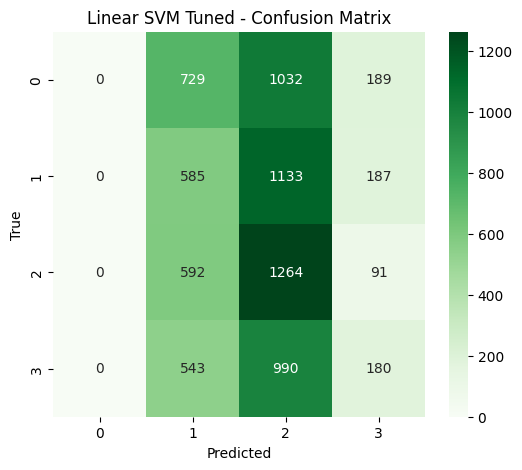

In [10]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens")
plt.title("Linear SVM Tuned - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [11]:
#Krahasimi i SVM modeleve
comparison_df = pd.DataFrame(
    [basic_results] + pca_results + [tuned_results]
)

comparison_df[
    ["Model", "Accuracy", "Precision", "Recall", "F1-score", "Best Parameters"]
]

,Model,Accuracy,Precision,Recall,F1-score,Best Parameters
0,Linear SVM Basic GroupSplit 4-Class,0.308716,0.318939,0.308716,0.292040,"LinearSVC default, class_weight=balanced"
1,Linear SVM + PCA 20 GroupSplit 4-Class,0.316966,0.303445,0.316966,0.298994,"PCA n_components=20, LinearSVC default"
2,Linear SVM + PCA 50 GroupSplit 4-Class,0.379375,0.403576,0.379375,0.342244,"PCA n_components=50, LinearSVC default"
3,Linear SVM + PCA 100 GroupSplit 4-Class,0.345842,0.388720,0.345842,0.327787,"PCA n_components=100, LinearSVC default"
4,Linear SVM + PCA 150 GroupSplit 4-Class,0.330406,0.391607,0.330406,0.300395,"PCA n_components=150, LinearSVC default"
5,Linear SVM + PCA + RandomizedSearchCV GroupSpl...,0.269993,0.198075,0.269993,0.205773,"{'svm__loss': 'hinge', 'svm__C': 1, 'pca__n_co..."


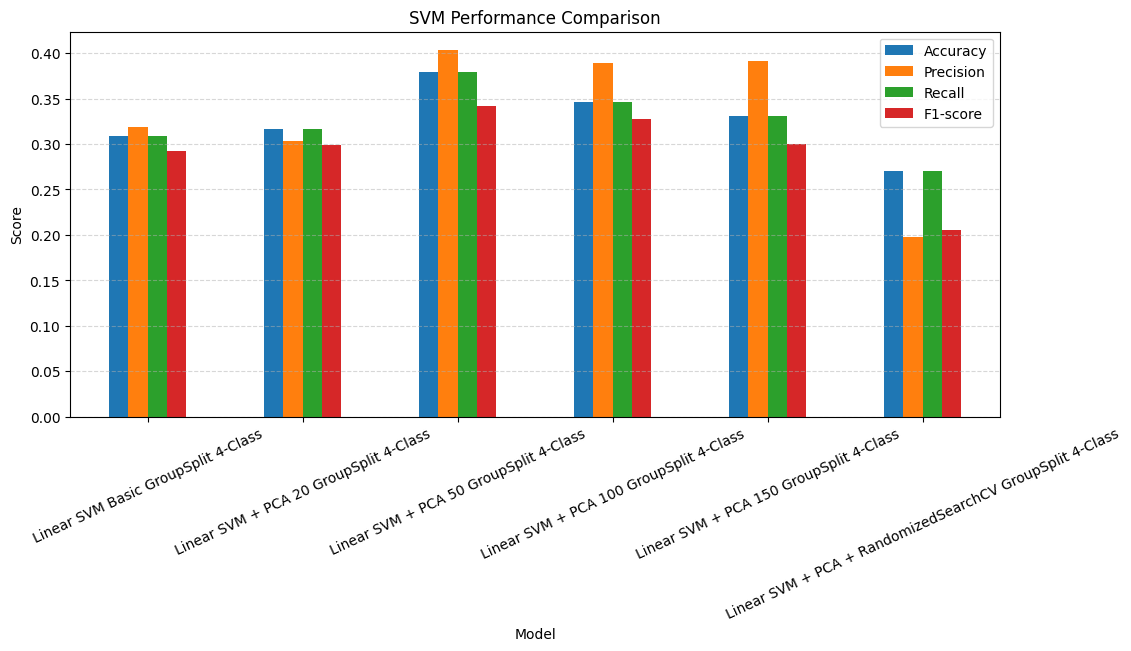

In [12]:
metrics_df = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

metrics_df.plot(kind="bar", figsize=(12, 5))

plt.title("SVM Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=25)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [13]:
comparison_df.to_csv(
    "../results/tables/svm_results.csv",
    index=False
)